# 04_Model_Interpretability_with_SHAP_and_LIME

### 💾 Block 1: Model Dictionary Initialization & Asset Loading
In this section, we load our dictionary of trained production models (`best_model_24h.pkl`, `best_model_48h.pkl`, and `best_model_72h.pkl`) from the disk storage. This centralized model dictionary allows us to map the correct champion model to its respective multi-horizon forecasting pipeline (24-hour, 48-hour, and 72-hour) for global and local interpretability.

In [ ]:
import joblib

# Ensure the filenames match exactly what you uploaded
champions = {
    "24h": joblib.load("best_model_24h (1).pkl"),
    "48h": joblib.load("best_model_48h (1).pkl"),
    "72h": joblib.load("best_model_72h.pkl")
}

print("Champions dictionary loaded successfully.")

Champions dictionary loaded successfully.


### 📊 Block 2: Global Feature Importance Across Forecasting Horizons (SHAP)
This block runs global SHAP (SHapley Additive exPlanations) analysis for our models across different forecasting horizons. By computing the SHAP values on our test set, we visually break down how features like chemical tracers, weather interactions, and multi-scale lags contribute to the model's global logic, explaining why a model shifts its reliance from autoregressive memory at 24h to seasonal/climatic trends at 72h.

Features now match X_numeric: (29136, 82)

--- Generating SHAP Summary for 24h ---


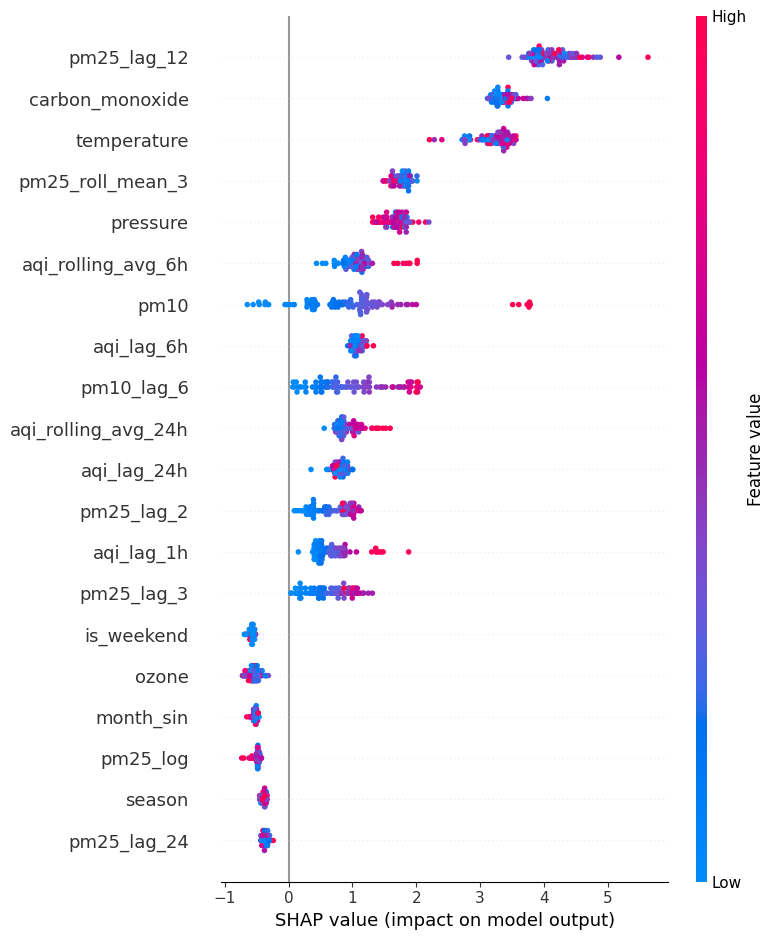


--- Generating SHAP Summary for 48h ---


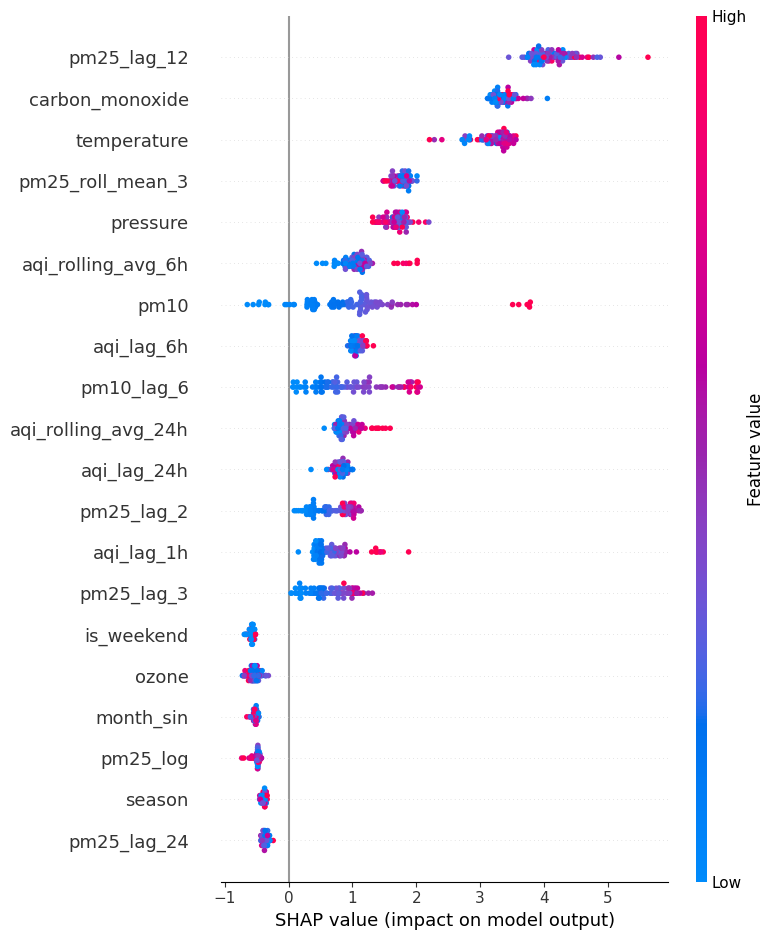


--- Generating SHAP Summary for 72h ---


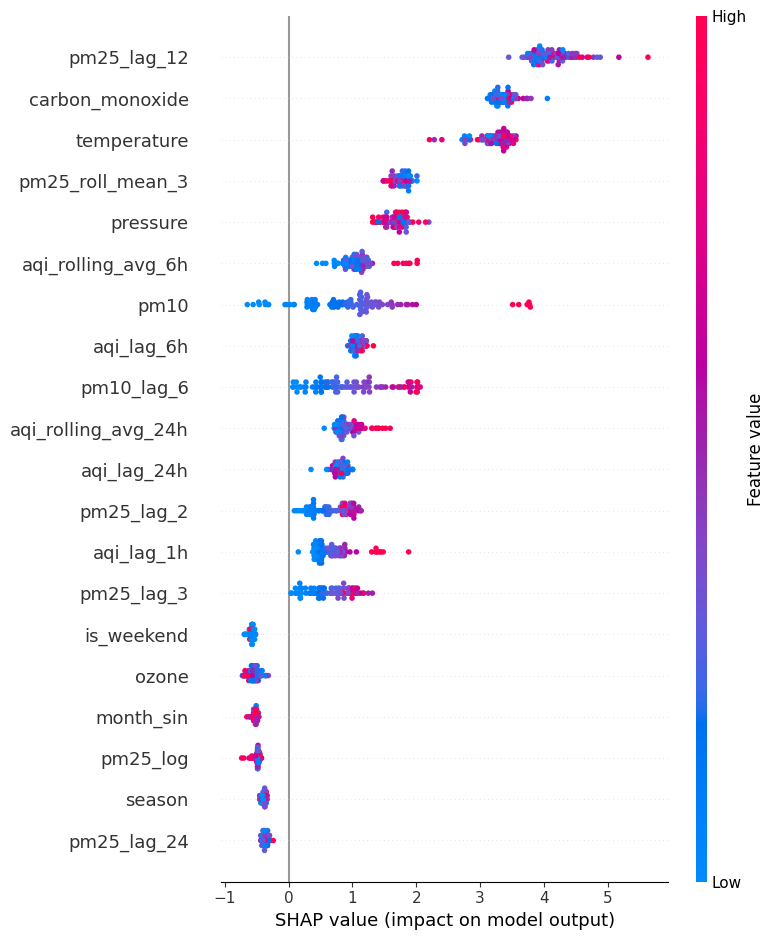

In [ ]:
# 1. Update the features list to remove any columns that aren't in X_numeric
# This keeps only the features that actually exist in your numeric data
features_clean = [f for f in features if f in X_numeric.columns]

# 2. Now filter using the cleaned list
X_numeric = X_numeric[features_clean]

# 3. Check that everything matches
print(f"Features now match X_numeric: {X_numeric.shape}")

# 4. Now run the SHAP analysis
background_data = X_numeric.sample(100, random_state=42)

for horizon, model in champions.items():
    print(f"\n--- Generating SHAP Summary for {horizon} ---")
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(background_data)
    shap.summary_plot(shap_values, background_data)

### 🟦 Block 3: Local Instance Explanation via LIME — Negative Contribution Analysis (Blue Bars)
Here, we utilize LIME (Local Interpretable Model-agnostic Explanations) to dissect specific, real-time prediction instances. This block focuses on the negative feature contributions (represented by the blue bars), highlighting the localized environmental and meteorological variables that are actively pulling the predicted AQI down and working to "cleanse" the atmosphere at that specific hour.

In [ ]:
# 1. Initialize the LIME Explainer
# We dynamically fetch feature names from the model itself to ensure the
# LIME explainer exactly matches the model's training expectations
model_24h = champions["24h"]

# Check if model has feature_names_in_ attribute (standard in modern scikit-learn)
if hasattr(model_24h, 'feature_names_in_'):
    model_feature_names = list(model_24h.feature_names_in_)
else:
    # Fallback to your globally defined feature list if attribute isn't available
    model_feature_names = features_clean

# Filter X_numeric to include only the features the model expects
X_for_lime = X_numeric[model_feature_names]

lime_explainer = LimeTabularExplainer(
    X_for_lime.values,
    feature_names=model_feature_names,
    mode="regression",
    verbose=False
)

# 2. Define a function to generate local explanations
def explain_with_lime(horizon, row_index):
    model = champions[horizon]

    # Explain the instance using the DataFrame row to maintain index alignment
    # Note: LIME explain_instance works best with the actual data point
    exp = lime_explainer.explain_instance(
        X_for_lime.iloc[row_index].values,
        model.predict,
        num_features=10
    )

    print(f"\n--- LIME Analysis for {horizon} horizon (Row {row_index}) ---")
    # This displays the interactive visualization in your notebook
    return exp.show_in_notebook()

# 3. Test it: Explain the most recent prediction (last row)
explain_with_lime("24h", -1)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



--- LIME Analysis for 24h horizon (Row -1) ---


### 🟧 Block 4: Local Instance Explanation via LIME — Positive Contribution Analysis (Orange Bars)
This final block uses LIME to evaluate the positive feature contributions (represented by the orange bars) for individual predictions. It pinpoints the exact triggers—such as sudden drops in ventilation index, traffic rush hours, or accumulating historical pollution levels—that are actively pushing the local AQI forecast higher into hazardous boundaries.

In [ ]:
# Find an index where the actual AQI was high (e.g., > 100)
# We assume 'target_24h' is the ground truth column
high_pollution_indices = df[df['target_24h'] > 100].index

if len(high_pollution_indices) > 0:
    print(f"Found high pollution day at index: {high_pollution_indices[0]}")
    explain_with_lime("24h", high_pollution_indices[0])
else:
    print("No high pollution days found in this sample.")

Found high pollution day at index: 105


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but ExtraTreesRegressor was fitted with feature names
  warnings.warn(



--- LIME Analysis for 24h horizon (Row 105) ---
